# Parallel Kalman Filter & SSM Natural Parameters

This notebook demonstrates the parallel (associative-scan) Kalman filter
and smoother, the Joseph-form covariance update, and the natural/expectation
parameter representations of linear-Gaussian state-space models.

**What you'll learn:**

1. Running `gaussx.parallel_kalman_filter` and `gaussx.parallel_rts_smoother`
2. Verifying equivalence with the sequential Kalman filter
3. The Joseph-form covariance update for numerical stability
4. Converting SSM parameters to natural parameters (`BlockTriDiag` precision)
5. Converting smoother output to expectation parameters and back

## Background: why parallelism matters

The standard Kalman filter is inherently sequential: each step depends on
the previous filtered state. On modern accelerators (GPU/TPU) this
sequential bottleneck limits throughput for long time series.

The **associative-scan** formulation (Sarkka & Garcia-Fernandez, 2021)
reformulates the Kalman recursion as a parallel prefix sum over a
semigroup of affine transformations. This enables $O(\log T)$ parallel
depth instead of $O(T)$ sequential steps, while producing identical
results up to floating-point precision.

In gaussx, `parallel_kalman_filter` and `parallel_rts_smoother` provide
the same interface as their sequential counterparts but use dense array
operations that are faster on GPU/TPU for long sequences.

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## Define the model

We reuse the **damped oscillator** from the sequential Kalman filter
notebook. The 2D state $x_t = [\text{position}, \text{velocity}]^\top$
follows a discretized spring-mass-damper system, and only position is
observed with noise.

- $A$: discretized spring-mass-damper transition
- $H = \begin{bmatrix} 1 & 0 \end{bmatrix}$ (observe position only)
- $Q$: process noise driving the oscillator
- $R = [0.5]$: observation noise variance

In [2]:
dt = 0.1
T = 200

# Damped oscillator: omega=1.0 rad/s, damping gamma=0.15
omega, gamma = 1.0, 0.15
A = jnp.array([[1.0, dt], [-(omega**2) * dt, 1.0 - gamma * dt]])

# Observation matrix (observe position only)
H = jnp.array([[1.0, 0.0]])

# Process noise covariance
q_var = 0.3
Q = q_var * jnp.array([[dt**3 / 3, dt**2 / 2], [dt**2 / 2, dt]])

# Observation noise covariance
R = jnp.array([[0.5]])

print("A =\n", A)
print("H =", H)
print("Q =\n", Q)
print("R =", R)

A =
 [[ 1.     0.1  ]
 [-0.1    0.985]]
H = [[1. 0.]]
Q =
 [[0.0001 0.0015]
 [0.0015 0.03  ]]
R = [[0.5]]


## Simulate data

Generate $T = 200$ time steps from the model. The true trajectory is
sampled from the generative process so the Kalman filter assumptions
are satisfied.

In [3]:
key = jax.random.PRNGKey(42)


def simulate_step(carry, key_t):
    x = carry
    k1, k2 = jax.random.split(key_t)
    q_t = jax.random.multivariate_normal(k1, jnp.zeros(2), Q)
    x_new = A @ x + q_t
    r_t = jax.random.multivariate_normal(k2, jnp.zeros(1), R)
    y_t = H @ x_new + r_t
    return x_new, (x_new, y_t)


x0 = jnp.array([3.0, 0.0])  # displaced from equilibrium, at rest
keys = jax.random.split(key, T)
_, (true_states, observations) = jax.lax.scan(simulate_step, x0, keys)

times = jnp.arange(T) * dt
true_position = true_states[:, 0]

print("true_states shape:", true_states.shape)
print("observations shape:", observations.shape)

true_states shape: (200, 2)
observations shape: (200, 1)


## Run parallel Kalman filter and smoother

In [4]:
init_mean = jnp.zeros(2)
init_cov = jnp.eye(2) * 4.0

# Parallel filter
par_filter_state = gaussx.parallel_kalman_filter(
    A, H, Q, R, observations, init_mean, init_cov
)

print("Parallel filtered means shape:", par_filter_state.filtered_means.shape)
print("Parallel log-likelihood:", par_filter_state.log_likelihood)

Parallel filtered means shape: (200, 2)
Parallel log-likelihood: -223.3188576581507


In [5]:
# Parallel smoother
par_smooth_means, par_smooth_covs = gaussx.parallel_rts_smoother(par_filter_state, A, Q)

print("Parallel smoothed means shape:", par_smooth_means.shape)
print("Parallel smoothed covs shape:", par_smooth_covs.shape)

Parallel smoothed means shape: (200, 2)
Parallel smoothed covs shape: (200, 2, 2)


## Compare with sequential Kalman filter

The parallel and sequential implementations should produce identical
results (up to floating-point precision). We verify this by comparing
filtered means, covariances, and the log-likelihood.

In [6]:
# Sequential filter
seq_filter_state = gaussx.kalman_filter(A, H, Q, R, observations, init_mean, init_cov)

# Sequential smoother
seq_smooth_means, seq_smooth_covs = gaussx.rts_smoother(seq_filter_state, A, Q)

# Compare filtered means
mean_diff = jnp.max(
    jnp.abs(par_filter_state.filtered_means - seq_filter_state.filtered_means)
)
print(f"Max abs diff (filtered means): {mean_diff:.2e}")

# Compare filtered covariances
cov_diff = jnp.max(
    jnp.abs(par_filter_state.filtered_covs - seq_filter_state.filtered_covs)
)
print(f"Max abs diff (filtered covs):  {cov_diff:.2e}")

# Compare log-likelihoods
ll_diff = jnp.abs(par_filter_state.log_likelihood - seq_filter_state.log_likelihood)
print(f"Abs diff (log-likelihood):     {ll_diff:.2e}")

# Compare smoothed means
smooth_mean_diff = jnp.max(jnp.abs(par_smooth_means - seq_smooth_means))
print(f"Max abs diff (smoothed means): {smooth_mean_diff:.2e}")

# Compare smoothed covariances
smooth_cov_diff = jnp.max(jnp.abs(par_smooth_covs - seq_smooth_covs))
print(f"Max abs diff (smoothed covs):  {smooth_cov_diff:.2e}")

Max abs diff (filtered means): 1.05e-15
Max abs diff (filtered covs):  4.44e-16


Abs diff (log-likelihood):     0.00e+00
Max abs diff (smoothed means): 4.00e-15
Max abs diff (smoothed covs):  8.88e-16


## Joseph-form covariance update

The standard Kalman update computes the posterior covariance as
$P = (I - KH) P_{\text{pred}}$, but this can lose symmetry or positive
definiteness due to round-off. The **Joseph form** is more robust:

$$P = (I - KH) P_{\text{pred}} (I - KH)^\top + K R K^\top$$

We manually compute the Kalman gain at one time step and compare both
formulas.

In [7]:
# Pick a time step to illustrate
t_idx = 50
P_pred = par_filter_state.predicted_covs[t_idx]  # (2, 2)
x_pred = par_filter_state.predicted_means[t_idx]  # (2,)

# Compute Kalman gain K = P_pred H^T (H P_pred H^T + R)^{-1}
S = H @ P_pred @ H.T + R
K = P_pred @ H.T @ jnp.linalg.inv(S)

print(f"Time step {t_idx}:")
print(f"Kalman gain K =\n{K}")

# Standard update: (I - KH) P_pred
d_state = P_pred.shape[0]
P_standard = (jnp.eye(d_state) - K @ H) @ P_pred

# Joseph-form update
P_joseph = gaussx.joseph_update(P_pred, K, H, R)

print(f"\nStandard update P =\n{P_standard}")
print(f"\nJoseph update P =\n{P_joseph}")
print(f"\nMax abs difference: {jnp.max(jnp.abs(P_standard - P_joseph)):.2e}")

# The Joseph form guarantees symmetry
print(f"\nStandard symmetry error: {jnp.max(jnp.abs(P_standard - P_standard.T)):.2e}")
print(f"Joseph symmetry error:   {jnp.max(jnp.abs(P_joseph - P_joseph.T)):.2e}")

Time step 50:
Kalman gain K =
[[0.16284017]
 [0.13551443]]



Standard update P =
[[0.08142008 0.06775721]
 [0.06775721 0.21846408]]

Joseph update P =
[[0.08142008 0.06775721]
 [0.06775721 0.21846408]]

Max abs difference: 9.71e-17

Standard symmetry error: 1.94e-16
Joseph symmetry error:   0.00e+00


## SSM natural parameters

A linear-Gaussian state-space model defines a joint Gaussian
$p(x_0, \ldots, x_{T-1})$ whose precision matrix is **block-tridiagonal**.
The function `ssm_to_naturals` extracts the natural parameters
$(\theta_1, \theta_2)$ where $\theta_2 = -\tfrac{1}{2}\Lambda$ is
stored as a `BlockTriDiag` operator.

The API expects `Q` to have shape `(N, d, d)` where `Q[0]` is the initial
covariance $P_0$ and `Q[1:]` contains the process noise at each step.

In [8]:
# Build the full Q array: Q[0] = P_0, Q[1:] = process noise
d_state = A.shape[0]
Q_full = jnp.concatenate([init_cov[None], jnp.tile(Q, (T - 1, 1, 1))], axis=0)
A_full = jnp.tile(A, (T - 1, 1, 1))

print("A_full shape:", A_full.shape)
print("Q_full shape:", Q_full.shape)
print("Q_full[0] (= P_0):\n", Q_full[0])

A_full shape: (199, 2, 2)
Q_full shape: (200, 2, 2)
Q_full[0] (= P_0):
 [[4. 0.]
 [0. 4.]]


In [9]:
# Convert to natural parameters
theta_linear, theta_precision = gaussx.ssm_to_naturals(
    A_full, Q_full, init_mean, Q_full[0]
)

print("theta_linear shape:", theta_linear.shape)
print("theta_precision type:", type(theta_precision).__name__)
print("theta_precision diagonal shape:", theta_precision.diagonal.shape)
print("theta_precision sub_diagonal shape:", theta_precision.sub_diagonal.shape)

theta_linear shape: (400,)
theta_precision type: BlockTriDiag
theta_precision diagonal shape: (200, 2, 2)
theta_precision sub_diagonal shape: (199, 2, 2)


### Inspect the `BlockTriDiag` structure

The `BlockTriDiag` operator stores `(N, d, d)` diagonal blocks and
`(N-1, d, d)` sub-diagonal blocks. Its dense representation is a
$(Nd \times Nd)$ matrix with the characteristic banded sparsity
pattern of a Gauss-Markov chain.

In [10]:
# Materialize the dense precision matrix (small enough for T=200, d=2)
dense_precision = theta_precision.as_matrix()
print("Dense precision shape:", dense_precision.shape)

Dense precision shape: (400, 400)


In [11]:
# Round-trip: convert back to SSM parameters
A_rt, Q_rt, mu0_rt, P0_rt = gaussx.naturals_to_ssm(theta_linear, theta_precision)

print("Round-trip A max error:", jnp.max(jnp.abs(A_rt - A_full)).item())
print("Round-trip Q max error:", jnp.max(jnp.abs(Q_rt - Q_full)).item())
print("Round-trip mu_0 max error:", jnp.max(jnp.abs(mu0_rt - init_mean)).item())
print("Round-trip P_0 max error:", jnp.max(jnp.abs(P0_rt - init_cov)).item())

Round-trip A max error: 1.8197554574328478e-11
Round-trip Q max error: 8.177721610991284e-09
Round-trip mu_0 max error: 0.0
Round-trip P_0 max error: 8.177721610991284e-09


## SSM expectation parameters

Given smoothed marginals $(m_t, P_t)$ and cross-covariances
$C_t = \text{Cov}(x_{t+1}, x_t \mid y_{1:T})$, we can compute the
expectation parameters of the joint Gaussian:

- $\eta_1 = E[x]$ (concatenated means)
- $\eta_2$: a `BlockTriDiag` with diagonal blocks $E[x_t x_t^\top]$
  and sub-diagonal blocks $E[x_{t+1} x_t^\top]$

The cross-covariance is computed from the smoother gain:
$C_t = G_t P_{t+1|T}$ where $G_t = P_{t|t} A^\top P_{t+1|t}^{-1}$.

In [12]:
# Compute cross-covariances from filter/smoother outputs
# G_t = P_{t|t} A^T P_{t+1|t}^{-1}
# C_t = G_t @ P_{t+1|T}


def compute_cross_covs(filter_state, smoothed_covs, A):
    """Compute cross-covariances P_{t+1,t|T} = G_t @ P_{t+1|T}."""
    P_filt = filter_state.filtered_covs[:-1]  # (T-1, d, d)
    P_pred = filter_state.predicted_covs[1:]  # (T-1, d, d)
    P_smooth_next = smoothed_covs[1:]  # (T-1, d, d)

    def _one_step(P_f, P_p, P_s_next):
        G = jnp.linalg.solve(P_p.T, (P_f @ A.T).T).T
        return G @ P_s_next

    return jax.vmap(_one_step)(P_filt, P_pred, P_smooth_next)


cross_covs = compute_cross_covs(par_filter_state, par_smooth_covs, A)
print("Cross-covariances shape:", cross_covs.shape)

Cross-covariances shape: (199, 2, 2)


In [13]:
# Convert to expectation parameters
eta1, eta2 = gaussx.ssm_to_expectations(par_smooth_means, par_smooth_covs, cross_covs)

print("eta1 shape:", eta1.shape)
print("eta2 type:", type(eta2).__name__)
print("eta2 diagonal shape:", eta2.diagonal.shape)
print("eta2 sub_diagonal shape:", eta2.sub_diagonal.shape)

eta1 shape: (400,)
eta2 type: BlockTriDiag
eta2 diagonal shape: (200, 2, 2)
eta2 sub_diagonal shape: (199, 2, 2)


In [14]:
# Round-trip: convert back to SSM marginals
means_rt, covs_rt, cross_covs_rt = gaussx.expectations_to_ssm(eta1, eta2)

err_m = jnp.max(jnp.abs(means_rt - par_smooth_means)).item()
err_c = jnp.max(jnp.abs(covs_rt - par_smooth_covs)).item()
err_cc = jnp.max(jnp.abs(cross_covs_rt - cross_covs)).item()
print("Round-trip means max error:", err_m)
print("Round-trip covs max error:", err_c)
print("Round-trip cross_covs max error:", err_cc)

Round-trip means max error: 0.0
Round-trip covs max error: 8.604228440844963e-16
Round-trip cross_covs max error: 8.604228440844963e-16


## Visualizations

### BlockTriDiag sparsity pattern

The precision matrix of a Gauss-Markov chain has a characteristic
block-tridiagonal sparsity pattern. We visualize the first few blocks
to see this structure clearly.

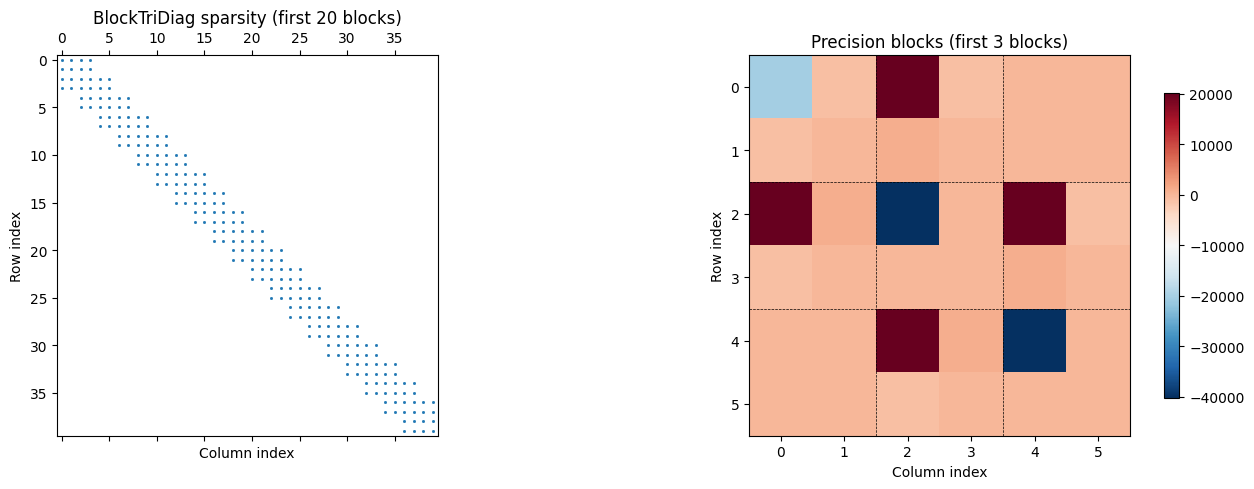

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sparsity pattern of the precision (show first 20 blocks = 40x40)
n_show = min(20, T)
d_show = n_show * d_state
prec_sub = dense_precision[:d_show, :d_show]

ax = axes[0]
ax.spy(jnp.abs(prec_sub) > 1e-12, markersize=1, color="C0")
ax.set_title(f"BlockTriDiag sparsity (first {n_show} blocks)")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")

# Zoom into a 3-block region to see the structure
n_zoom = 3
d_zoom = n_zoom * d_state
prec_zoom = dense_precision[:d_zoom, :d_zoom]

ax = axes[1]
im = ax.imshow(prec_zoom, cmap="RdBu_r", aspect="equal")
ax.set_title(f"Precision blocks (first {n_zoom} blocks)")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")
# Draw block boundaries
for i in range(1, n_zoom):
    ax.axhline(i * d_state - 0.5, color="k", lw=0.5, ls="--")
    ax.axvline(i * d_state - 0.5, color="k", lw=0.5, ls="--")
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

### Filtered vs smoothed estimates

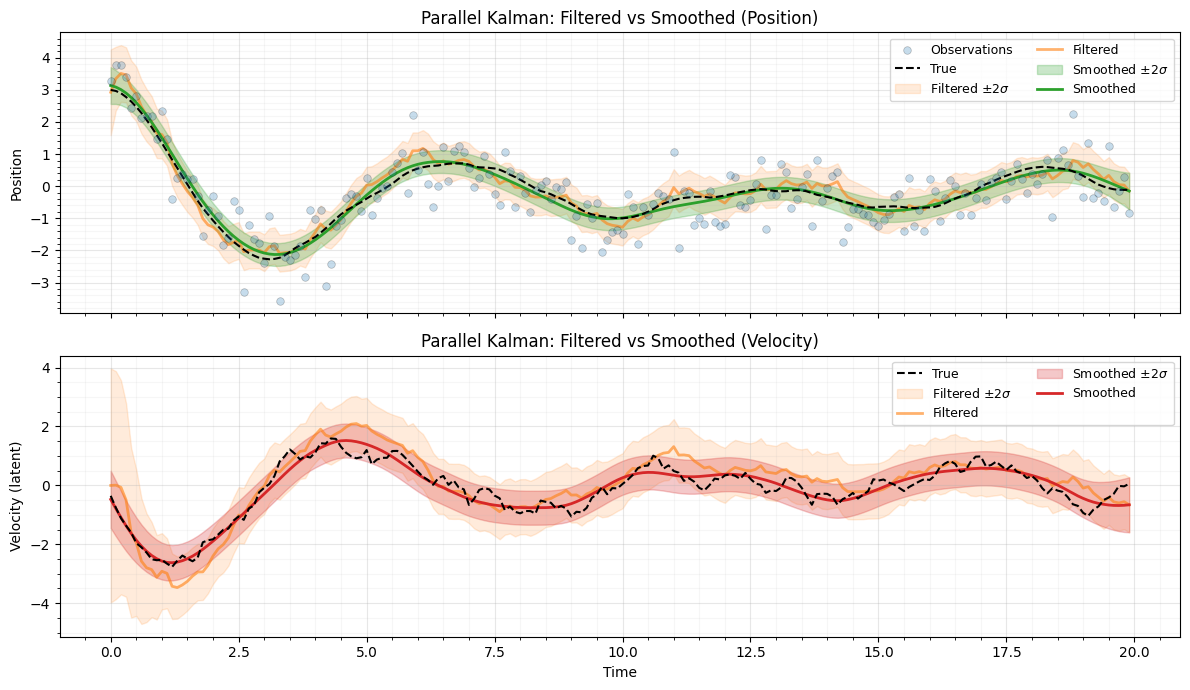

In [16]:
filt_pos_mean = par_filter_state.filtered_means[:, 0]
filt_pos_std = jnp.sqrt(par_filter_state.filtered_covs[:, 0, 0])
smooth_pos_mean = par_smooth_means[:, 0]
smooth_pos_std = jnp.sqrt(par_smooth_covs[:, 0, 0])

filt_vel_mean = par_filter_state.filtered_means[:, 1]
filt_vel_std = jnp.sqrt(par_filter_state.filtered_covs[:, 1, 1])
smooth_vel_mean = par_smooth_means[:, 1]
smooth_vel_std = jnp.sqrt(par_smooth_covs[:, 1, 1])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Position
ax = axes[0]
ax.scatter(
    times,
    observations[:, 0],
    s=30,
    c="C0",
    edgecolors="k",
    linewidths=0.5,
    alpha=0.25,
    label="Observations",
    zorder=5,
)
ax.plot(times, true_position, "k--", lw=1.5, label="True", zorder=4)
ax.fill_between(
    times,
    filt_pos_mean - 2 * filt_pos_std,
    filt_pos_mean + 2 * filt_pos_std,
    color="C1",
    alpha=0.15,
    label=r"Filtered $\pm 2\sigma$",
)
ax.plot(times, filt_pos_mean, "C1-", lw=2, alpha=0.6, label="Filtered", zorder=3)
ax.fill_between(
    times,
    smooth_pos_mean - 2 * smooth_pos_std,
    smooth_pos_mean + 2 * smooth_pos_std,
    color="C2",
    alpha=0.25,
    label=r"Smoothed $\pm 2\sigma$",
)
ax.plot(times, smooth_pos_mean, "C2-", lw=2, label="Smoothed", zorder=3)
ax.set_ylabel("Position")
ax.set_title("Parallel Kalman: Filtered vs Smoothed (Position)")
ax.legend(loc="upper right", fontsize=9, ncol=2)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

# Velocity
ax = axes[1]
ax.plot(times, true_states[:, 1], "k--", lw=1.5, label="True", zorder=4)
ax.fill_between(
    times,
    filt_vel_mean - 2 * filt_vel_std,
    filt_vel_mean + 2 * filt_vel_std,
    color="C1",
    alpha=0.15,
    label=r"Filtered $\pm 2\sigma$",
)
ax.plot(times, filt_vel_mean, "C1-", lw=2, alpha=0.6, label="Filtered", zorder=3)
ax.fill_between(
    times,
    smooth_vel_mean - 2 * smooth_vel_std,
    smooth_vel_mean + 2 * smooth_vel_std,
    color="C3",
    alpha=0.25,
    label=r"Smoothed $\pm 2\sigma$",
)
ax.plot(times, smooth_vel_mean, "C3-", lw=2, label="Smoothed", zorder=3)
ax.set_xlabel("Time")
ax.set_ylabel("Velocity (latent)")
ax.set_title("Parallel Kalman: Filtered vs Smoothed (Velocity)")
ax.legend(loc="upper right", fontsize=9, ncol=2)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

plt.tight_layout()
plt.show()

## Summary

- **Parallel Kalman filter**: `gaussx.parallel_kalman_filter` produces
  identical results to the sequential `gaussx.kalman_filter` but uses
  dense array operations suited for GPU/TPU acceleration.
- **Parallel RTS smoother**: `gaussx.parallel_rts_smoother` likewise
  matches the sequential smoother.
- **Joseph-form update**: `gaussx.joseph_update` computes the Kalman
  covariance update in a numerically stable form that preserves symmetry
  and positive-definiteness.
- **Natural parameters**: `gaussx.ssm_to_naturals` extracts the
  block-tridiagonal precision (as a `BlockTriDiag` operator) and the
  linear natural parameter from SSM matrices. `gaussx.naturals_to_ssm`
  inverts this exactly.
- **Expectation parameters**: `gaussx.ssm_to_expectations` converts
  smoother marginals (means, covariances, cross-covariances) to
  expectation parameters with `BlockTriDiag` second moments.
  `gaussx.expectations_to_ssm` inverts this exactly.
- The `BlockTriDiag` operator exploits Gauss-Markov sparsity for
  $O(Nd^3)$ operations instead of $O((Nd)^3)$ dense cost.

## References

- Sarkka, S. & Garcia-Fernandez, A. F. (2021). Temporal parallelization
  of Bayesian smoothers. *IEEE Trans. Automatic Control*, 66(1), 299--306.
- Kalman, R. E. (1960). A new approach to linear filtering and prediction
  problems. *J. Basic Engineering*, 82(1), 35--45.
- Rauch, H. E., Tung, F., & Striebel, C. T. (1965). Maximum likelihood
  estimates of linear dynamic systems. *AIAA Journal*, 3(8), 1445--1450.
- Sarkka, S. (2013). *Bayesian Filtering and Smoothing*. Cambridge
  University Press.